In [7]:
import pandas as pd
pd.options.display.max_columns = 999

import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import plotly.io as pio
pio.renderers.default = 'notebook'

from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing, model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
from collections import Counter


In [6]:
path = "C:/datascientest/fire_brigade/data/"
clean_merge = pd.read_csv(f'{path}clean_merge_v2.xls', sep=";")

In [8]:
clean_merge=clean_merge.drop(['DateAndTimeMobilised', 'DateAndTimeMobile', 'DateAndTimeArrived', 'Incident_Date'], axis=1)

In [9]:
num_vars2=clean_merge[['AttendanceTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'Notional Cost (£)', 'distance_km', 'PumpOrder', 'Month_compat_mobs', 'CalYear_compat_mobs', 'HourOfCall_compat_mobs']]

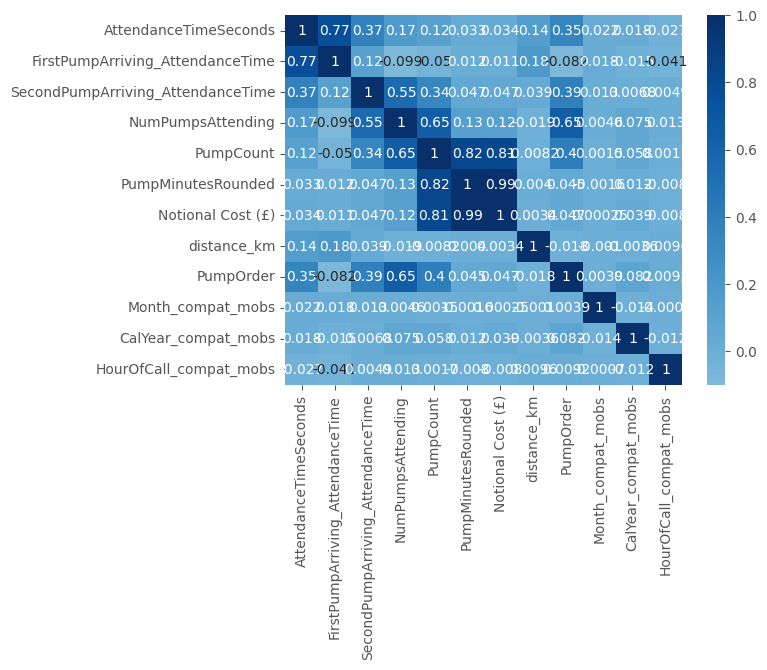

In [10]:
sns.heatmap(num_vars2.corr(), annot=True, cmap='Blues', center=0)
plt.show(sns)

In [11]:
clean_merge=clean_merge.drop(['DateOfCall', 'IncidentNumber'], axis=1)

In [12]:
clean_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514797 entries, 0 to 1514796
Data columns (total 29 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   CalYear_compat_mobs                     1514797 non-null  int64  
 1   HourOfCall_compat_mobs                  1514797 non-null  int64  
 2   PerformanceReporting                    1514797 non-null  object 
 3   TurnoutTimeSeconds                      1514797 non-null  float64
 4   TravelTimeSeconds                       1514797 non-null  float64
 5   AttendanceTimeSeconds                   1514797 non-null  float64
 6   DeployedFromStation_Name                1514797 non-null  object 
 7   DeployedFromLocation                    1514797 non-null  object 
 8   PumpOrder                               1514797 non-null  int64  
 9   DelayCode_Description                   1514797 non-null  object 
 10  Weekday_compat_mobs           

In [13]:
clean_merge.nunique()

CalYear_compat_mobs                           16
HourOfCall_compat_mobs                        24
PerformanceReporting                           3
TurnoutTimeSeconds                           805
TravelTimeSeconds                           1187
AttendanceTimeSeconds                       1200
DeployedFromStation_Name                     116
DeployedFromLocation                           2
PumpOrder                                     11
DelayCode_Description                         12
Weekday_compat_mobs                            7
Month_compat_mobs                             12
IncidentGroup                                  3
StopCodeDescription                           28
PropertyCategory                               9
AddressQualifier                              11
Postcode_district                            317
ProperCase                                    33
IncidentStationGround                        102
FirstPumpArriving_AttendanceTime            1200
FirstPumpArriving_De

In [193]:
cat_cols=clean_merge.select_dtypes(include=['object'])

In [195]:
num_cols=clean_merge[['HourOfCall_compat_mobs', 'Month_compat_mobs', 'CalYear_compat_mobs', 'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds', 'Notional Cost (£)', 'distance_km', 'PumpMinutesRounded', 'PumpCount', 'NumPumpsAttending', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'NumStationsWithPumpsAttending', 'NumStationsWithPumpsAttending', 'PumpOrder']]
num_cols.head()

,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder
0,0,1,2009,253.0,89.0,342.0,255.0,1.691595,60.0,2.0,2.0,319.0,342.0,2.0,2.0,2
1,0,1,2009,151.0,157.0,308.0,255.0,0.639746,60.0,1.0,1.0,308.0,-1.0,1.0,1.0,1
2,0,1,2009,108.0,102.0,210.0,255.0,0.425043,60.0,1.0,1.0,210.0,-1.0,1.0,1.0,1
3,0,1,2009,114.0,119.0,233.0,255.0,1.162546,60.0,2.0,2.0,233.0,250.0,1.0,1.0,1
4,0,1,2009,83.0,89.0,172.0,255.0,0.563928,60.0,2.0,2.0,172.0,222.0,1.0,1.0,1


In [197]:
low_cardinality = []
high_cardinality = []
for col in cat_cols:
    if clean_merge[col].nunique() <=10:
        low_cardinality.append(col)
    else:
        high_cardinality.append(col)

print(low_cardinality)
print(high_cardinality)

['PerformanceReporting', 'DeployedFromLocation', 'Weekday_compat_mobs', 'IncidentGroup', 'PropertyCategory']
['DeployedFromStation_Name', 'DelayCode_Description', 'StopCodeDescription', 'AddressQualifier', 'Postcode_district', 'ProperCase', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']


In [199]:
def frequency_encode(clean_merge, columns):
    for col in columns:
        freq_map = clean_merge[col].value_counts() / len(clean_merge)
        clean_merge[col] = clean_merge[col].map(freq_map)
    return clean_merge

clean_merge_encoded = frequency_encode(clean_merge.copy(), high_cardinality)

In [201]:
clean_merge_encoded.head()

,CalYear_compat_mobs,HourOfCall_compat_mobs,PerformanceReporting,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,DelayCode_Description,Weekday_compat_mobs,Month_compat_mobs,IncidentGroup,StopCodeDescription,PropertyCategory,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),distance_km
0,2009,0,2,253.0,89.0,342.0,0.010037,Home Station,2,0.469475,Thursday,1,Special Service,0.036991,Road Vehicle,0.035991,0.009080,0.033752,0.008562,319.0,0.007963,342.0,0.006378,2.0,2.0,2.0,60.0,255.0,1.691595
1,2009,0,1,151.0,157.0,308.0,0.011193,Home Station,1,0.469475,Thursday,1,Fire,0.070277,Outdoor,0.056977,0.005213,0.028938,0.011889,308.0,0.010859,-1.0,0.400062,1.0,1.0,1.0,60.0,255.0,0.639746
2,2009,0,1,108.0,102.0,210.0,0.009930,Home Station,1,0.469475,Thursday,1,Fire,0.070277,Outdoor,0.054395,0.002425,0.032239,0.009477,210.0,0.010137,-1.0,0.400062,1.0,1.0,1.0,60.0,255.0,0.425043
3,2009,0,1,114.0,119.0,233.0,0.011176,Home Station,1,0.469475,Thursday,1,Fire,0.070277,Outdoor,0.056977,0.007462,0.031730,0.012184,233.0,0.011459,250.0,0.005921,1.0,2.0,2.0,60.0,255.0,1.162546
4,2009,0,1,83.0,89.0,172.0,0.017569,Home Station,1,0.005381,Thursday,1,False Alarm,0.446464,Dwelling,0.596625,0.003932,0.050151,0.016787,172.0,0.017036,222.0,0.013082,1.0,2.0,2.0,60.0,255.0,0.563928


In [203]:
clean_merge_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514797 entries, 0 to 1514796
Data columns (total 29 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   CalYear_compat_mobs                     1514797 non-null  int64  
 1   HourOfCall_compat_mobs                  1514797 non-null  int64  
 2   PerformanceReporting                    1514797 non-null  object 
 3   TurnoutTimeSeconds                      1514797 non-null  float64
 4   TravelTimeSeconds                       1514797 non-null  float64
 5   AttendanceTimeSeconds                   1514797 non-null  float64
 6   DeployedFromStation_Name                1514797 non-null  float64
 7   DeployedFromLocation                    1514797 non-null  object 
 8   PumpOrder                               1514797 non-null  int64  
 9   DelayCode_Description                   1514797 non-null  float64
 10  Weekday_compat_mobs           

In [205]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
X= clean_merge_encoded.drop(columns = ['AttendanceTimeSeconds'])
y= clean_merge_encoded['AttendanceTimeSeconds']

low_cardinality = [col for col in X.select_dtypes(include=['object']).columns if col not in high_cardinality]

onehot_encoder = OneHotEncoder(sparse_output=False, drop = 'first')

X_onehot_encoded = onehot_encoder.fit_transform(X[low_cardinality])
onehot_columns = onehot_encoder.get_feature_names_out(low_cardinality)
X_onehot_encoded_df = pd.DataFrame(X_onehot_encoded, columns = onehot_columns)
X_onehot_encoded_num_df = pd.concat([X_onehot_encoded_df, num_cols], axis=1)

X_high_cardinality = X[high_cardinality]
X_combined=pd.concat([X_onehot_encoded_num_df, X_high_cardinality], axis =1)

X_combined=X_combined.drop(columns=['AttendanceTimeSeconds'])

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)


In [207]:
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,23.0,441.0,364.0,0.629166,60.0,2.0,2.0,359.0,464.0,2.0,2.0,2,0.008850,0.065598,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,75.0,181.0,352.0,1.575489,60.0,2.0,2.0,256.0,537.0,2.0,2.0,1,0.005018,0.469475,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,87.0,354.0,260.0,1.233103,60.0,3.0,3.0,292.0,370.0,2.0,2.0,3,0.007053,0.469475,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,47.0,194.0,724.0,0.146880,112.0,6.0,5.0,163.0,241.0,5.0,5.0,2,0.012220,0.469475,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,69.0,214.0,430.0,1.810568,60.0,2.0,2.0,245.0,283.0,1.0,1.0,2,0.016094,0.016444,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [209]:
X_combined.to_csv('X_combined.csv', sep=';', index=False)

In [299]:
y_test.to_csv('y_test.csv', sep=';', index=False)

In [211]:
y_test.head()

75412      519.0
1293925    314.0
321430     332.0
193403     208.0
791040     533.0
Name: AttendanceTimeSeconds, dtype: float64

In [213]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1060357 entries, 1217440 to 121958
Data columns (total 43 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   PerformanceReporting_2                  1060357 non-null  float64
 1   PerformanceReporting_Not Used           1060357 non-null  float64
 2   DeployedFromLocation_Other Station      1060357 non-null  float64
 3   Weekday_compat_mobs_Monday              1060357 non-null  float64
 4   Weekday_compat_mobs_Saturday            1060357 non-null  float64
 5   Weekday_compat_mobs_Sunday              1060357 non-null  float64
 6   Weekday_compat_mobs_Thursday            1060357 non-null  float64
 7   Weekday_compat_mobs_Tuesday             1060357 non-null  float64
 8   Weekday_compat_mobs_Wednesday           1060357 non-null  float64
 9   IncidentGroup_Fire                      1060357 non-null  float64
 10  IncidentGroup_Special Service 

In [215]:
from sklearn.preprocessing import MinMaxScaler
scaler1 = MinMaxScaler()
X_train[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']]=scaler1.fit_transform(X_train[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,60.0,2.0,2.0,0.298582,0.387177,2.0,2.0,2,0.008850,0.065598,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,60.0,2.0,2.0,0.212677,0.447960,2.0,2.0,1,0.005018,0.469475,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,60.0,3.0,3.0,0.242702,0.308909,2.0,2.0,3,0.007053,0.469475,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,112.0,6.0,5.0,0.135113,0.201499,5.0,5.0,2,0.012220,0.469475,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,60.0,2.0,2.0,0.203503,0.236470,1.0,1.0,2,0.016094,0.016444,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [217]:
X_test[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']]=scaler1.transform(X_test[['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'distance_km', 'Notional Cost (£)']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,126.0,3.0,3.0,0.331943,0.427977,2.0,2.0,3,0.012495,0.469475,0.124588,0.596625,0.002917,0.043056,0.011998,0.011941,0.007763
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,66.0,2.0,1.0,0.261051,0.000000,1.0,1.0,1,0.014593,0.205798,0.013480,0.596625,0.003034,0.033084,0.017900,0.014972,0.400062
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,86.0,3.0,3.0,0.102585,0.277269,2.0,2.0,2,0.002809,0.004734,0.124588,0.596625,0.016483,0.043056,0.021189,0.019520,0.000910
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,60.0,4.0,4.0,0.172644,0.179850,2.0,2.0,1,0.013075,0.469475,0.006629,0.596625,0.006405,0.039432,0.013731,0.013129,0.009319
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,60.0,1.0,1.0,0.443703,0.000000,1.0,1.0,1,0.005804,0.065598,0.047718,0.596625,0.011125,0.030405,0.010013,0.005375,0.400062


In [219]:
from sklearn.preprocessing import RobustScaler
scalerR = RobustScaler()
X_train[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']]=scalerR.fit_transform(X_train[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,0.0,0.0,0.0,0.298582,0.387177,1.0,1.0,1.0,0.008850,0.065598,0.446464,0.596625,0.005498,0.036353,0.007806,0.006483,0.004922
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,0.0,0.0,0.0,0.212677,0.447960,1.0,1.0,0.0,0.005018,0.469475,0.446464,0.596625,0.020174,0.038847,0.005050,0.005204,0.000354
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,0.0,1.0,1.0,0.242702,0.308909,1.0,1.0,2.0,0.007053,0.469475,0.446464,0.215888,0.002934,0.032239,0.011167,0.011124,0.007266
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,52.0,4.0,3.0,0.135113,0.201499,4.0,4.0,1.0,0.012220,0.469475,0.446464,0.596625,0.015615,0.045372,0.005945,0.005492,0.009166
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,0.0,0.0,0.0,0.203503,0.236470,0.0,0.0,1.0,0.016094,0.016444,0.446464,0.215888,0.004583,0.028316,0.016247,0.015956,0.010162


In [221]:
X_test[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']]=scalerR.transform(X_test[['NumPumpsAttending', 'PumpCount', 'PumpMinutesRounded', 'PumpOrder', 'NumStationsWithPumpsAttending']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,66.0,1.0,1.0,0.331943,0.427977,1.0,1.0,2.0,0.012495,0.469475,0.124588,0.596625,0.002917,0.043056,0.011998,0.011941,0.007763
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,6.0,0.0,-1.0,0.261051,0.000000,0.0,0.0,0.0,0.014593,0.205798,0.013480,0.596625,0.003034,0.033084,0.017900,0.014972,0.400062
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,26.0,1.0,1.0,0.102585,0.277269,1.0,1.0,1.0,0.002809,0.004734,0.124588,0.596625,0.016483,0.043056,0.021189,0.019520,0.000910
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,0.0,2.0,2.0,0.172644,0.179850,1.0,1.0,0.0,0.013075,0.469475,0.006629,0.596625,0.006405,0.039432,0.013731,0.013129,0.009319
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,0.0,-1.0,-1.0,0.443703,0.000000,0.0,0.0,0.0,0.005804,0.065598,0.047718,0.596625,0.011125,0.030405,0.010013,0.005375,0.400062


In [223]:
from sklearn.preprocessing import StandardScaler
scalerS=StandardScaler()
X_train[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']] = scalerS.fit_transform(X_train[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']])
X_train.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
1217440,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,6,2022,0.010772,0.360475,0.000252,0.023666,0.0,0.0,0.0,0.298582,0.387177,1.0,1.0,1.0,-0.473577,0.065598,1.094149,0.596625,-0.154289,0.062503,-0.729742,-0.896915,-0.830543
1101752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21,4,2021,0.057451,0.139949,0.000224,0.059665,0.0,0.0,0.0,0.212677,0.447960,1.0,1.0,0.0,-1.126830,0.469475,1.094149,0.596625,3.418578,0.236340,-1.192239,-1.122726,-0.854296
200757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11,3,2011,0.068223,0.286684,0.000012,0.046640,0.0,1.0,1.0,0.242702,0.308909,1.0,1.0,2.0,-0.779892,0.469475,1.094149,0.215888,-0.778508,-0.224172,-0.165662,-0.077256,-0.818358
1409175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1,2024,0.032316,0.150975,0.001082,0.005319,52.0,4.0,3.0,0.135113,0.201499,4.0,4.0,1.0,0.100902,0.469475,1.094149,0.596625,2.308676,0.690963,-1.042025,-1.071782,-0.808476
1488445,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,9,2024,0.052065,0.167939,0.000404,0.068608,0.0,0.0,0.0,0.203503,0.236470,0.0,0.0,1.0,0.761245,0.016444,1.094149,0.215888,-0.377202,-0.497508,0.686772,0.775978,-0.803299


In [225]:
X_test[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']] = scalerS.transform(X_test[['DeployedFromStation_Name', 'ProperCase', 'StopCodeDescription', 'Postcode_district', 'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation']])
X_test.head()

,PerformanceReporting_2,PerformanceReporting_Not Used,DeployedFromLocation_Other Station,Weekday_compat_mobs_Monday,Weekday_compat_mobs_Saturday,Weekday_compat_mobs_Sunday,Weekday_compat_mobs_Thursday,Weekday_compat_mobs_Tuesday,Weekday_compat_mobs_Wednesday,IncidentGroup_Fire,IncidentGroup_Special Service,PropertyCategory_Boat,PropertyCategory_Dwelling,PropertyCategory_Non Residential,PropertyCategory_Other Residential,PropertyCategory_Outdoor,PropertyCategory_Outdoor Structure,PropertyCategory_Rail Vehicle,PropertyCategory_Road Vehicle,HourOfCall_compat_mobs,Month_compat_mobs,CalYear_compat_mobs,TurnoutTimeSeconds,TravelTimeSeconds,Notional Cost (£),distance_km,PumpMinutesRounded,PumpCount,NumPumpsAttending,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumStationsWithPumpsAttending,PumpOrder,DeployedFromStation_Name,DelayCode_Description,StopCodeDescription,AddressQualifier,Postcode_district,ProperCase,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
75412,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15,11,2009,0.072711,0.348601,0.000672,0.052484,66.0,1.0,1.0,0.331943,0.427977,1.0,1.0,2.0,0.147716,0.469475,-0.631508,0.596625,-0.782687,0.529593,-0.026304,0.066951,-0.815773
1293925,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16,1,2023,0.078097,0.169635,0.000335,0.035025,6.0,0.0,-1.0,0.261051,0.000000,0.0,0.0,0.0,0.505345,0.205798,-1.227189,0.596625,-0.754240,-0.165291,0.964159,0.602277,1.224011
321430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,18,7,2012,0.118492,0.146735,0.000272,0.004884,26.0,1.0,1.0,0.102585,0.277269,1.0,1.0,1.0,-1.503365,0.004734,-0.631508,0.596625,2.519857,0.529593,1.516053,1.405383,-0.851406
193403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,2011,0.061939,0.094996,0.000012,0.013803,0.0,2.0,2.0,0.172644,0.179850,1.0,1.0,0.0,0.246632,0.469475,-1.263919,0.596625,0.066373,0.277050,0.264487,0.276792,-0.807679
791040,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,2018,0.070916,0.362171,0.000168,0.101415,0.0,-1.0,-1.0,0.443703,0.000000,0.0,0.0,0.0,-0.992804,0.065598,-1.043629,0.596625,1.215489,-0.351962,-0.359302,-1.092533,1.224011


In [227]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [229]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1060357 entries, 1217440 to 121958
Data columns (total 43 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   PerformanceReporting_2                  1060357 non-null  float64
 1   PerformanceReporting_Not Used           1060357 non-null  float64
 2   DeployedFromLocation_Other Station      1060357 non-null  float64
 3   Weekday_compat_mobs_Monday              1060357 non-null  float64
 4   Weekday_compat_mobs_Saturday            1060357 non-null  float64
 5   Weekday_compat_mobs_Sunday              1060357 non-null  float64
 6   Weekday_compat_mobs_Thursday            1060357 non-null  float64
 7   Weekday_compat_mobs_Tuesday             1060357 non-null  float64
 8   Weekday_compat_mobs_Wednesday           1060357 non-null  float64
 9   IncidentGroup_Fire                      1060357 non-null  float64
 10  IncidentGroup_Special Service 

In [231]:
Xx_train=X_train.drop(['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime'], axis=1)

In [233]:
Xx_test=X_test.drop(['TurnoutTimeSeconds', 'TravelTimeSeconds', 'FirstPumpArriving_AttendanceTime'], axis=1)

In [235]:
Xx_train.to_csv('Xx_train.csv', sep=';', index=False)

In [237]:
Xx_test.to_csv('Xx_test.csv', sep=';', index=False)

In [393]:
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
rf_regressor.fit(Xx_train, y_train)
y_pred=rf_regressor.predict(Xx_test)
mse= mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean squared error:", mse)
print("\nn")
print("Root mean squared error:", rmse)
print("\nn")
print("R2 score:", r2)

Mean squared error: 6182.622772365079

n
Root mean squared error: 78.62965580724031

n
R2 score: 0.7311251347198982


In [481]:
from sklearn.model_selection import GridSearchCV

param_grid= {
    'n_estimators': [100, 300],
    'max_depth': [10, 20],
    'min_samples_split': [5, 20],
    'min_samples_leaf': [2, 6]
}

grid_search = GridSearchCV(estimator = rf_regressor, param_grid = param_grid, cv=3, n_jobs=1, verbose = 2, error_score='raise', refit=True)
grid_search.fit(Xx_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=20.1min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=20.1min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=20.1min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time= 6.7min
[CV] END max_depth=10, min_

In [485]:
rf_tuned=grid_search.best_estimator_
y_pred_tuned=rf_tuned.predict(Xx_test)
accuracy_score(y_test, y_pred_tuned)
recall_score(y_test, y_pred_tuned)
precision_score(y_test, y_pred_tuned)
mean_squared_error(y_test, y_pred_tuned)

NameError: name 'accuracy_score' is not defined

In [530]:
mse2= mean_squared_error(y_test, y_pred_tuned)
rmse2=np.sqrt(mse2)
r22 = r2_score(y_test, y_pred_tuned)
print("Mean squared error:", mse2)
print("\nn")
print("Root mean squared error:", rmse2)
print("\nn")
print("R2 score:", r22)

Mean squared error: 6189.393127231419

n
Root mean squared error: 78.67269619907162

n
R2 score: 0.7308307000892229


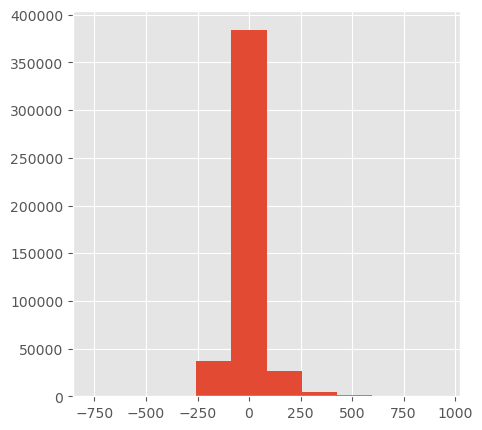

In [583]:
results=pd.DataFrame(zip(y_test, y_pred_tuned, y_test-y_pred_tuned), columns = ['y_test', 'y_pred_tuned', 'error'])
results.head()
plt.figure(figsize=(5,5))
results['error'].hist()
plt.savefig("Results_rf_regression_error_tuned.png")
plt.show()


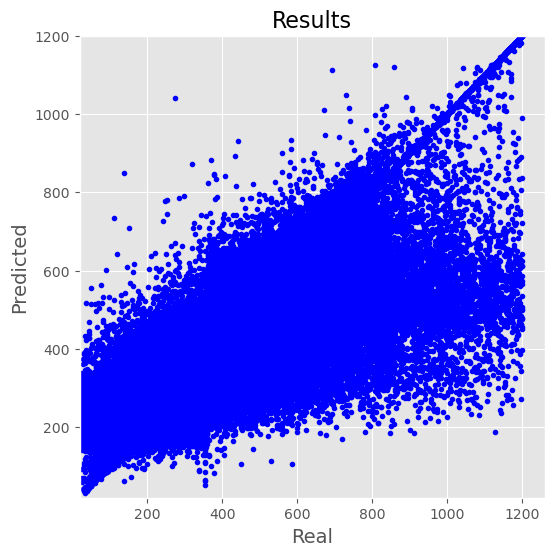

In [595]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results['y_test'], results['y_pred_tuned'], 'b.')
plt.plot(x, x, 'r-')
plt.xlim(20.1200)
plt.ylim(20,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.savefig("Results_rf_regression_tuned.png")
plt.show(plt)

In [545]:
rf_regressor3 = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=5, min_samples_leaf=6, random_state=42)
rf_regressor3.fit(Xx_train, y_train)
y_pred3=rf_regressor3.predict(Xx_test)
mse3= mean_squared_error(y_test, y_pred3)
rmse3=np.sqrt(mse)
r23 = r2_score(y_test, y_pred3)
print("Mean squared error:", mse3)
print("\nn")
print("Root mean squared error:", rmse3)
print("\nn")
print("R2 score:", r23)

Mean squared error: 6186.60771375743

n
Root mean squared error: 78.62965580724031

n
R2 score: 0.7309518343877468


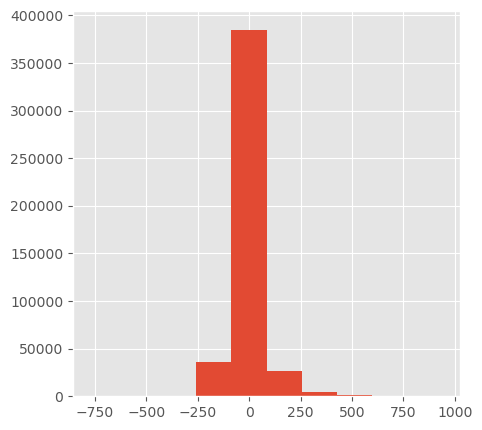

In [581]:
results3=pd.DataFrame(zip(y_test, y_pred3, y_test-y_pred3), columns = ['y_test', 'y_pred3', 'error'])
results3.head()
plt.figure(figsize=(5,5))
plt.savefig("Results_rf_regression3.png")
results3['error'].hist()
plt.show()


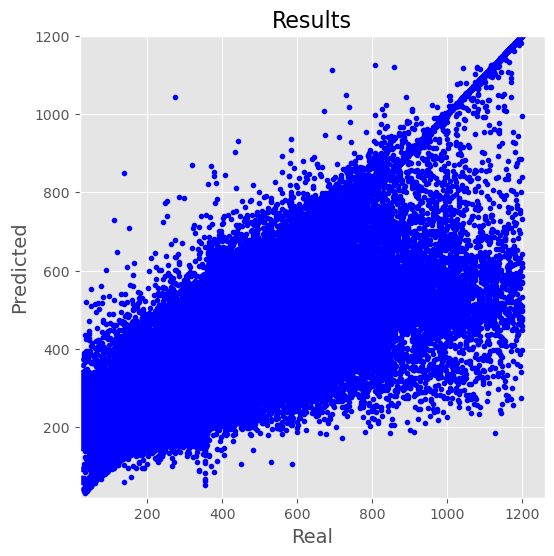

In [591]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results3['y_test'], results3['y_pred3'], 'b.')
plt.plot(x, x, 'r-')
plt.xlim(20.1200)
plt.ylim(20,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.savefig("Results_rf_regressio3n.png")
plt.show(plt)

In [239]:
Xxx_train=Xx_train.drop(['DeployedFromStation_Name', 'SecondPumpArriving_DeployedFromStation' ], axis=1)
Xxx_test=Xx_test.drop(['DeployedFromStation_Name', 'SecondPumpArriving_DeployedFromStation' ], axis=1)

In [241]:
Xxx_train.to_csv('Xxx_train.csv', sep=';', index=False)

In [242]:
Xxx_test.to_csv('Xxx_test.csv', sep=';', index=False)

In [259]:
rf_regressor4 = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=5, min_samples_leaf=6, random_state=42)
rf_regressor4.fit(Xxx_train, y_train)
y_pred4=rf_regressor4.predict(Xxx_test)
mse4= mean_squared_error(y_test, y_pred4)
rmse4=np.sqrt(mse4)
r24 = r2_score(y_test, y_pred4)
print("Mean squared error:", mse4)
print("\nn")
print("Root mean squared error:", rmse4)
print("\nn")
print("R2 score:", r24)

Mean squared error: 6230.152589118602

n
Root mean squared error: 78.93131564289678

n
R2 score: 0.7290581198708743


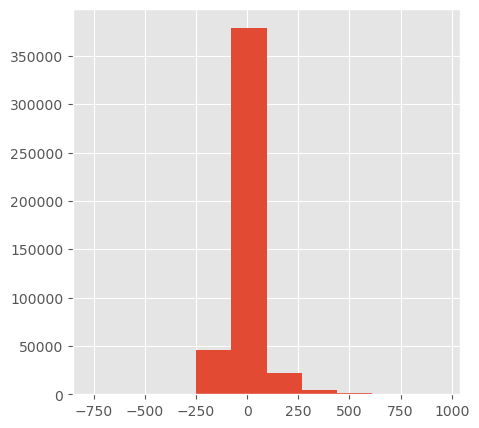

In [260]:
results4=pd.DataFrame(zip(y_test, y_pred4, y_test-y_pred4), columns = ['y_test', 'y_pred4', 'error'])
results4.head()
plt.figure(figsize=(5,5))
results4['error'].hist()
plt.savefig("Results_rf_regression_error4.png")
plt.show()

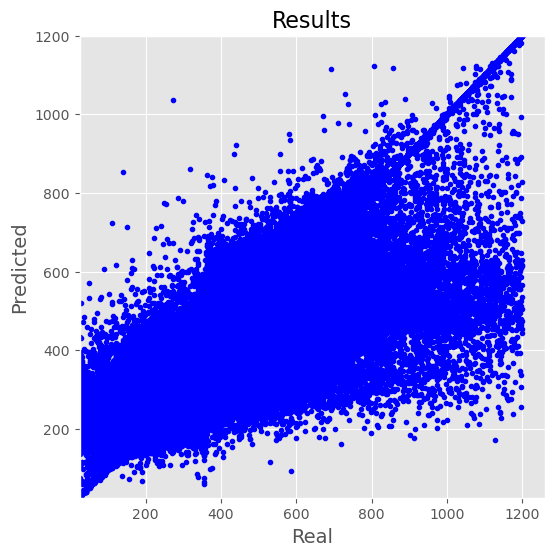

In [261]:
plt.figure(figsize=(6,6))
x=np.linspace(0,5,5)
plt.plot(results4['y_test'], results4['y_pred4'], 'b.')
plt.plot(x, x, 'r-')
plt.xlim(25.1200)
plt.ylim(25,1200)
plt.title("Results", fontsize=16)
plt.xlabel("Real", fontsize=14)
plt.ylabel("Predicted", fontsize=14)
plt.savefig("Results_rf_regression4.png")
plt.show(plt)

In [279]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [262]:
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error
model_lr = LinearRegression()
model_lr.fit(Xx_train, y_train)

LinearRegression()

In [263]:
print("score train:", model_lr.score(Xx_train, y_train))
print("score test:", model_lr.score(Xx_test, y_test))

score train: 0.515418834853856
score test: 0.5152111305242222


In [264]:
pred = model_lr.predict(Xx_train)
pred_test=model_lr.predict(Xx_test)

In [265]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred_test)))

RMSE Train: 105.34879345476642
RMSE Test: 105.58144262355123


In [266]:
from sklearn.linear_model import ElasticNetCV
model_en= ElasticNetCV (alphas=None, l1_ratio=0.5)
model_en.fit(Xx_train, y_train)

ElasticNetCV()

In [267]:
print("score train:", model_en.score(Xx_train, y_train))
print("score test:", model_en.score(Xx_test, y_test))

score train: 0.08411866407734159
score test: 0.08417016038176295


In [268]:
pred_en = model_en.predict(Xx_train)
pred_test_en=model_en.predict(Xx_test)

In [269]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred_en)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred_test_en)))

RMSE Train: 144.8324594374687
RMSE Test: 145.11712525797336


In [271]:
from sklearn.linear_model import ElasticNetCV
model2_en= ElasticNetCV (cv=12, l1_ratio=(0.1, 0.25, 0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99),
                         alphas=(0.00001, 0.00005, 0.0001, 0.00015, 0.0002, 0.005, 0.01, 0.02, 0.025, 0.05, 0.1, 0.25, 0.5, 0.8, 0.85, 0.9, 1.0), max_iter=10000000, random_state=42)
model2_en.fit(Xx_train, y_train)

print("Best alpha:", model2_en.alphas)
print("Best L1 ratio:", model2_en.l1_ratio)

Best alpha: (1e-05, 5e-05, 0.0001, 0.00015, 0.0002, 0.005, 0.01, 0.02, 0.025, 0.05, 0.1, 0.25, 0.5, 0.8, 0.85, 0.9, 1.0)
Best L1 ratio: (0.1, 0.25, 0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99)


In [272]:
print("score train:", model2_en.score(Xx_train, y_train))
print("score test:", model2_en.score(Xx_test, y_test))

score train: 0.5154186301391122
score test: 0.5152100443806102


In [273]:
pred2_en = model2_en.predict(Xx_train)
pred2_test_en=model2_en.predict(Xx_test)

In [274]:
print("RMSE Train:", np.sqrt(mean_squared_error(y_train, pred2_en)))
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, pred2_test_en)))

RMSE Train: 105.34881570743589
RMSE Test: 105.58156089828114
